In [178]:
import os
import pandas as pd
import plotly.express as px
import plotly.offline as pyo
import shutil
df=pd.read_csv('data/gdp_data.csv')
df.head()

,CountryName,CountryCode,Year,Value
0,Arab World,ARB,1968,2.576068e+10
1,Arab World,ARB,1969,2.843420e+10
2,Arab World,ARB,1970,3.138550e+10
3,Arab World,ARB,1971,3.642691e+10
4,Arab World,ARB,1972,4.331606e+10


In [126]:
df['CountryName'].describe()


count                      11507
unique                       256
top       Caribbean small states
freq                          57
Name: CountryName, dtype: object

In [127]:
df['CountryCode'].describe()

count     11507
unique      256
top         CSS
freq         57
Name: CountryCode, dtype: object

In [128]:
df['Year'].describe()

count    11507.000000
mean      1991.265230
std         15.886648
min       1960.000000
25%       1978.000000
50%       1993.000000
75%       2005.000000
max       2016.000000
Name: Year, dtype: float64

In [129]:
df['Year'].min()


1960

In [130]:
df['Year'].max()

2016

In [131]:
df_pr=df[df['CountryName']=='Arab World']

<Axes: xlabel='YEARS', ylabel='GDP'>

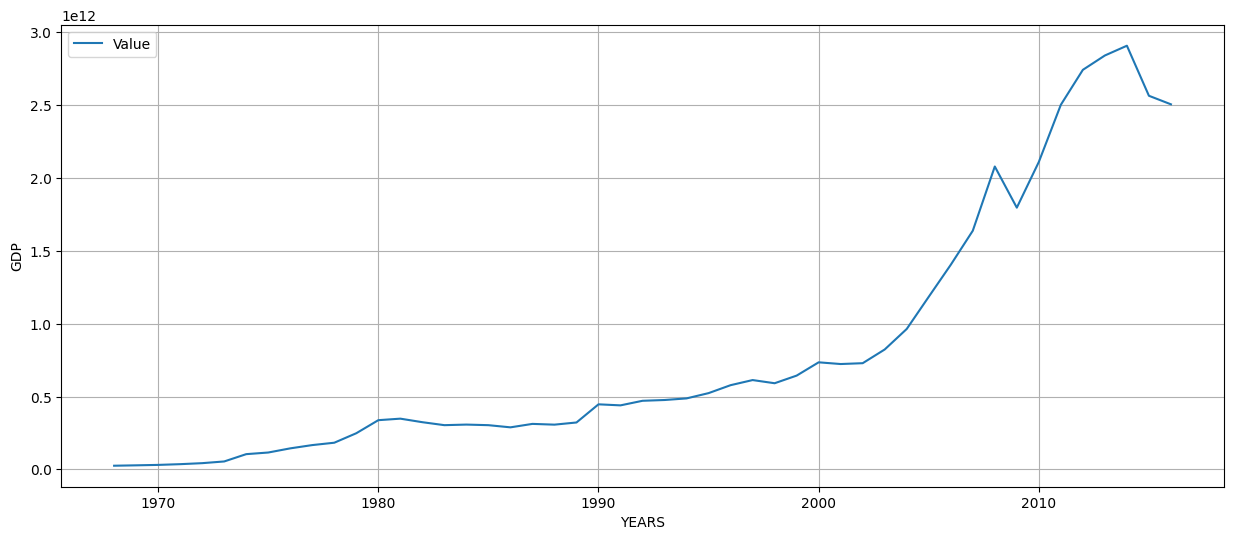

In [132]:
df_pr.plot(kind='line',x='Year',y='Value',figsize=(15,6),grid=True,
          ylabel='GDP',
          xlabel='YEARS')

In [133]:
#1968-2576
#1969-2843
#1970-3138

In [134]:
round(((2843-2576)/2576)*100,2)

10.36

In [50]:
df_pr.head()

,CountryName,CountryCode,Year,Value
0,Arab World,ARB,1968,2.576068e+10
1,Arab World,ARB,1969,2.843420e+10
2,Arab World,ARB,1970,3.138550e+10
3,Arab World,ARB,1971,3.642691e+10
4,Arab World,ARB,1972,4.331606e+10


In [71]:
df_pr=df[df['CountryName']=='India']

In [93]:
df_pr=df[df['CountryName']=='China']
data=df_pr.values
gdp_change=[0]
for i in range(1,len(data)):
    prev=data[i-1][3]
    curr=data[i][3]
    year=data[i][2]
    #print(year,round(((curr-prev)/prev)*100,2))
    gdp_change.append(round(((curr-prev)/prev)*100,2))
df_pr.assign(GDP=gdp_change)

,CountryName,CountryCode,Year,Value,GDP
4046,China,CHN,1960,5.971647e+10,0.00
4047,China,CHN,1961,5.005687e+10,-16.18
4048,China,CHN,1962,4.720936e+10,-5.69
4049,China,CHN,1963,5.070680e+10,7.41
4050,China,CHN,1964,5.970834e+10,17.75
4051,China,CHN,1965,7.043627e+10,17.97
4052,China,CHN,1966,7.672029e+10,8.92
4053,China,CHN,1967,7.288163e+10,-5.00
4054,China,CHN,1968,7.084654e+10,-2.79
4055,China,CHN,1969,7.970591e+10,12.51


# <font size="6">FINDING GDP GROWTH of a Country</font>


In [102]:
df_pr=df[df['CountryName']=='Arab World']
data=df_pr.values
gdp_change=[0]
for i in range(1,len(data)):
    prev=data[i-1][3]
    curr=data[i][3]
    year=data[i][2]
    #print(year,round(((curr-prev)/prev)*100,2))
    gdp_change.append(round(((curr-prev)/prev)*100,2))
df_pr.assign(GDP=gdp_change)

,CountryName,CountryCode,Year,Value,GDP
0,Arab World,ARB,1968,2.576068e+10,0.00
1,Arab World,ARB,1969,2.843420e+10,10.38
2,Arab World,ARB,1970,3.138550e+10,10.38
3,Arab World,ARB,1971,3.642691e+10,16.06
4,Arab World,ARB,1972,4.331606e+10,18.91
5,Arab World,ARB,1973,5.501839e+10,27.02
6,Arab World,ARB,1974,1.051458e+11,91.11
7,Arab World,ARB,1975,1.163370e+11,10.64
8,Arab World,ARB,1976,1.448462e+11,24.51
9,Arab World,ARB,1977,1.673083e+11,15.51


<font face="Courier New" color="blue" size="5">#FINDING GDP GROWTH OF WVERY COUNTRY</font>


In [113]:
final_data=[]
for country_name in df['CountryName'].unique():
    df_pr=df[df['CountryName']==country_name]
    data=df_pr.values
    gdp_change=[0]
    for i in range(1,len(data)):
        prev=data[i-1][3]
        curr=data[i][3]
        year=data[i][2]
        gdp_change.append(round(((curr-prev)/prev)*100,2))
    df_pr=df_pr.assign(GDP=gdp_change)
    final_data.append(df_pr)

In [114]:
df=pd.concat(final_data,axis=0)

In [115]:
df.head()

,CountryName,CountryCode,Year,Value,GDP
0,Arab World,ARB,1968,2.576068e+10,0.00
1,Arab World,ARB,1969,2.843420e+10,10.38
2,Arab World,ARB,1970,3.138550e+10,10.38
3,Arab World,ARB,1971,3.642691e+10,16.06
4,Arab World,ARB,1972,4.331606e+10,18.91


In [123]:
df.groupby('CountryName')['Value'].max().sort_values(ascending=False).head(50)

CountryName
World                                                   7.904923e+13
High income                                             5.036240e+13
OECD members                                            4.937008e+13
Post-demographic dividend                               4.673504e+13
IDA & IBRD total                                        2.948247e+13
Low & middle income                                     2.870476e+13
Middle income                                           2.829277e+13
IBRD only                                               2.739661e+13
Europe & Central Asia                                   2.365470e+13
East Asia & Pacific                                     2.248043e+13
Upper middle income                                     2.221220e+13
North America                                           2.016030e+13
Late-demographic dividend                               1.970310e+13
European Union                                          1.913667e+13
United States         

<font face="Courier New" color="blue" size="5">PLOTTING</font>


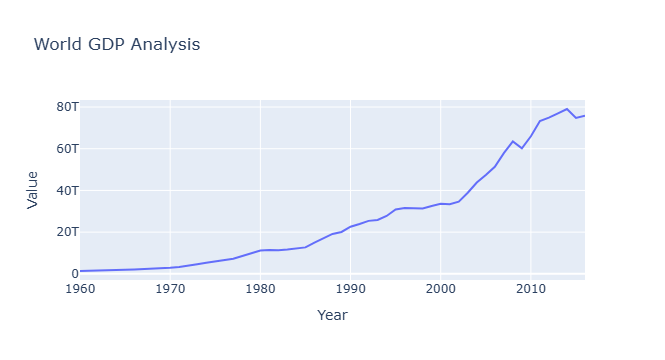

In [146]:
df_pr=df[df['CountryName']=='World']
fig=px.line(df_pr,x='Year',y='Value',title='World GDP Analysis')
fig

In [151]:
pyo.plot(fig,filename='World GDP.html')

'World GDP.html'

In [156]:
df_pr=df[df['CountryName']=='India']
fig=px.line(df_pr,x='Year',y='Value',title='Indian GDP Analysis')
pyo.plot(fig,filename='Indian GDP Analysis.html')

'Indian GDP Analysis.html'

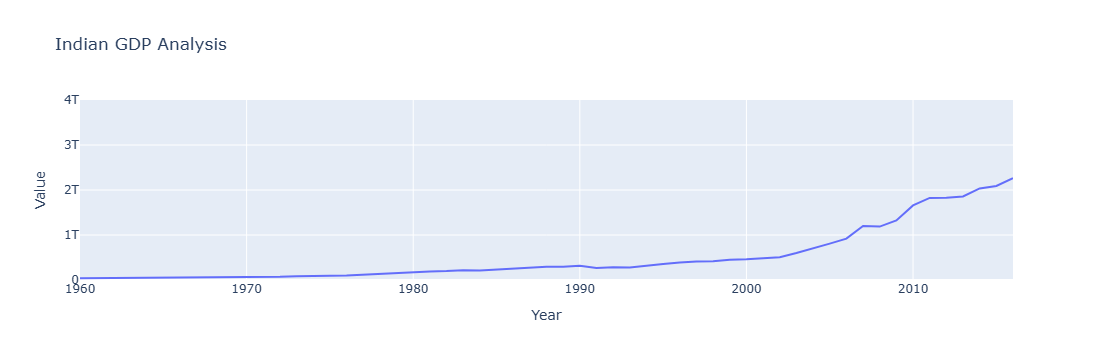

In [157]:
df_pr=df[df['CountryName']=='India']
fig=px.line(df_pr,x='Year',y='Value',title='Indian GDP Analysis',range_y=[0,4000000000000])
fig

<font face="Courier New" color="blue" size="5"><b>PLOTTING IN BULK</b></font>


In [167]:
df['CountryName'].nunique()

256

<font color="purple"><b>GDP OF EACH COUNTRY</b></font>

In [180]:
os.mkdir('GDP Individual')
for country_name in df['CountryName'].unique():
    df_pr=df[df['CountryName']==country_name]
    fig=px.line(df_pr,x='Year',y='Value',title=country_name+'GDP Analysis')
    pyo.plot(fig,filename='GDP Individual/'+ country_name +'.html', auto_open=False)

In [179]:
#shutil.rmtree('GDP Individual') for deleting the folder

 # Level 6 GDP of each Country WRT 80Trillion

In [186]:
os.mkdir('GDP Individual WRT 80T')
for country_name in df['CountryName'].unique():
    df_pr=df[df['CountryName']==country_name]
    fig=px.line(df_pr,x='Year',y='Value',title=country_name+'GDP Analysis',range_y=[0,80000000000000])
    pyo.plot(fig,filename='GDP Individual WRT 80T/'+ country_name +'.html', auto_open=False)

In [185]:
#shutil.rmtree('GDP Individual WRT 80T')

## GDP of All The Countries

In [188]:

fig=px.line(df,x='Year',y='Value',title='GDP Analysis of All Countries',color='CountryName') #takig the orignal dataframe,i.e,df
pyo.plot(fig,filename= 'Countries GDP.html')

'Countries GDP.html'

## GDP C comparison between India and China


In [193]:
c1=df[df['CountryName']=='China']
c2=df[df['CountryName']=='India']
df_pr=pd.concat([c1,c2],axis=0)

In [194]:
df_pr

,CountryName,CountryCode,Year,Value
4046,China,CHN,1960,5.971647e+10
4047,China,CHN,1961,5.005687e+10
4048,China,CHN,1962,4.720936e+10
4049,China,CHN,1963,5.070680e+10
4050,China,CHN,1964,5.970834e+10
...,...,...,...,...
6126,India,IND,2012,1.827638e+12
6127,India,IND,2013,1.856722e+12
6128,India,IND,2014,2.035393e+12
6129,India,IND,2015,2.089865e+12


In [202]:
fig=px.line(df_pr,x='Year',y='Value',title='GDP Comparison | India And China',color='CountryName') #change df back to df_pr
pyo.plot(fig,filename = 'IND_CHIN.html')

'IND_CHIN.html'

# GDP C comparison between The World and China or SPECIFIC COUNTRIES

In [203]:
d1=df[df['CountryName']=='China']
d2=df[df['CountryName']=='World']
df_pr=pd.concat([d1,d2],axis=0)
fig=px.line(df_pr,x='Year',y='Value',title='GDP Comparison | World And China',color='CountryName') #change df back to df_pr
pyo.plot(fig,filename = 'WORLD_CHIN.html')

'WORLD_CHIN.html'

# NOW BETWEEN MULTIPLE COUNTRIES

In [204]:
lst=['ITA','USA','IND','CHN']

In [207]:
dfs=[]
for i in lst:
    dfs.append(df[df['CountryCode']==i])

    df_pr=pd.concat(dfs,axis=0)
    

In [208]:
df_pr['CountryName'].unique()

array(['Italy', 'United States', 'India', 'China'], dtype=object)

In [211]:
fig=px.line(df_pr,x='Year',y='Value',title='GDP Comparison -'+'_'.join(lst),color='CountryName') #change df back to df_pr
pyo.plot(fig,filename = '_'.join(lst)+'.html')

'ITA_USA_IND_CHN.html'

In [219]:
lst=['ITA','USA','IND','CHN']
def  compare_gdp(lst,isOpen):
    dfs=[]
    for i in lst:
        dfs.append(df[df['CountryCode']==i])
        df_pr=pd.concat(dfs,axis=0)
    fig=px.line(df_pr,x='Year',y='Value',title='GDP Comparison -'+'_'.join(lst),color='CountryName')
    pyo.plot(fig,filename = '_'.join(lst)+'.html',auto_open=isOpen)    

In [224]:
compare_gdp(['IND','ITA'],True)#if false ,the file will mot open
                                #if true ,file will open

In [210]:
'_'.join(lst)

'ITA_USA_IND_CHN'

####  
----------------

In [222]:
final_data=[]
for country_name in df['CountryName'].unique():
    df_pr=df[df['CountryName']==country_name]
    data=df_pr.values
    gdp_change=[0]
    for i in range(1,len(data)):
        prev=data[i-1][3]
        curr=data[i][3]
        year=data[i][2]
        gdp_change.append(round(((curr-prev)/prev)*100,2))
    df_pr=df_pr.assign(GDP=gdp_change)
    final_data.append(df_pr)
df=pd.concat(final_data,axis=0)
df.head()

,CountryName,CountryCode,Year,Value,GDP
0,Arab World,ARB,1968,2.576068e+10,0.00
1,Arab World,ARB,1969,2.843420e+10,10.38
2,Arab World,ARB,1970,3.138550e+10,10.38
3,Arab World,ARB,1971,3.642691e+10,16.06
4,Arab World,ARB,1972,4.331606e+10,18.91


In [235]:
lst=['ITA','USA','IND','CHN']
def  compare_gdp(lst,isOpen):
    dfs=[]
    for i in lst:
        dfs.append(df[df['CountryCode']==i])
        
        df_pr=pd.concat(dfs,axis=0)
    fig=px.line(df_pr,x='Year',y='GDP',title='GDP Comparison -'+'_'.join(lst),color='CountryName')
    pyo.plot(fig,filename = '_'.join(lst)+'.html',auto_open=isOpen)  

In [236]:
compare_gdp(['IND','USA','ITA','CHN'],True)

## GDP Growth Comaprison of all Countries


In [237]:
fig=px.line(df,x='Year',y='GDP',title='GDP Comparison',color='CountryName')#df instead of df_pr
pyo.plot(fig,filename = 'GDP Growth.html',auto_open=True)  

'GDP Growth.html'

## GDP Growth of All Countries Graph Individual

In [254]:
os.mkdir('GDP Growth Individual news')
for country_name in df['CountryCode'].unique():
    df_pr=df[df['CountryCode']==country_name]


    fig=px.line(df_pr,x='Year',y='GDP',title = country_name)
    pyo.plot(fig,filename = 'GDP Growth Individual news/'+country_name+'.html',auto_open=False)  

 ## GDP Growth between 1960-2016

In [263]:
dff=[]

for country_name in df['CountryCode'].unique():
    df_pr=df[df['CountryCode']==country_name]
    if(len(df_pr)==57):
        dff.append(df_pr)
df_pr=pd.concat(dff,axis=0)

In [264]:
df_pr

,CountryName,CountryCode,Year,Value,GDP
49,Caribbean small states,CSS,1960,2.004785e+09,0.00
50,Caribbean small states,CSS,1961,2.169733e+09,8.23
51,Caribbean small states,CSS,1962,2.289495e+09,5.52
52,Caribbean small states,CSS,1963,2.431592e+09,6.21
53,Caribbean small states,CSS,1964,2.626896e+09,8.03
...,...,...,...,...,...
11502,Zimbabwe,ZWE,2012,1.424249e+10,17.72
11503,Zimbabwe,ZWE,2013,1.545177e+10,8.49
11504,Zimbabwe,ZWE,2014,1.589105e+10,2.84
11505,Zimbabwe,ZWE,2015,1.630467e+10,2.60


In [265]:
fig=px.line(df_pr,x='Year',y='GDP',title = 'GDP Growth',color='CountryName')
pyo.plot(fig,filename = 'GDP Growthh'+country_name+'.html',auto_open=True)

'GDP GrowthhZWE.html'